# VAE for implied volatility surfaces

This notebook illustrates the approach in [**arXiv:2102.03945**](https://arxiv.org/abs/2102.03945) (*Variational Autoencoders: A Hands-Off Approach to Volatility*).

**Idea:** Learn a latent representation of full **40-point** surfaces (8 tenors × 5 deltas) with a **pointwise decoder** (latent $z$ plus coordinates at each grid point). **Incomplete** surfaces are completed by optimizing $z$ so the decoded vols match observed quotes.

**Dependencies:** `pip install -e ".[vae]"` (PyTorch). Training here uses **synthetic SABR** surfaces; substitute historical FX vol grids to mirror the paper’s empirical study.

In [37]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
for _base in [_root, *_root.parents]:
    if (_base / "rates_models").is_dir() and (_base / "pyproject.toml").is_file():
        if str(_base) not in sys.path:
            sys.path.insert(0, str(_base))
        break
else:
    raise RuntimeError("Open from repo root or pip install -e .")

import importlib

import matplotlib.pyplot as plt
import numpy as np
import rates_models.arbitrage
import rates_models.arbitrage_repair
import rates_models.vae_surface
import torch
from matplotlib import cm
from rates_models.arbitrage import validate_vol_surface_per_expiry_black76
from rates_models.vae_surface import (
    DELTAS,
    TENORS_YEARS,
    ArbitrageAwareConfig,
    TrainConfig,
    impute_surface_latent_search,
    make_synthetic_sabr_surfaces,
    strikes_for_surface_grid,
    train_vae,
    train_vae_arbitrage_aware,
)

plt.rcParams.update({"font.sans-serif": ["DejaVu Sans", "Arial", "sans-serif"]})

## 1. Train a small VAE on synthetic surfaces

Architecture matches the paper’s description: encoder and decoder each use **two hidden layers of 32 units**; latent dimension is tunable. The decoder is **pointwise**: each of the 40 outputs is an MLP applied to $[z \Vert \text{features}(\text{tenor}, \delta)]$.

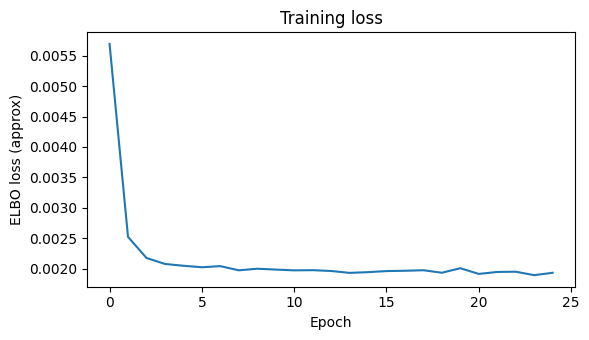

In [13]:
rng = np.random.default_rng(0)
n_train = 1500
surfaces = make_synthetic_sabr_surfaces(n_train, rng=rng)

cfg = TrainConfig(epochs=25, batch_size=64, latent_dim=8, lr=1e-3, kl_weight=1.0)
model, losses = train_vae(surfaces, cfg)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO loss (approx)")
ax.set_title("Training loss")
plt.tight_layout()
plt.show()

### Sampled surface from the calibrated decoder

After training, the decoder maps latent vectors $z$ to full $8\times5$ vol grids. Sampling $z \sim \mathcal{N}(0, I)$ and applying the decoder yields a **synthetic** surface drawn from the model’s generative distribution. The next cell plots it as a **3D surface** over delta and tenor (FX convention: smile across strikes / deltas by maturity).

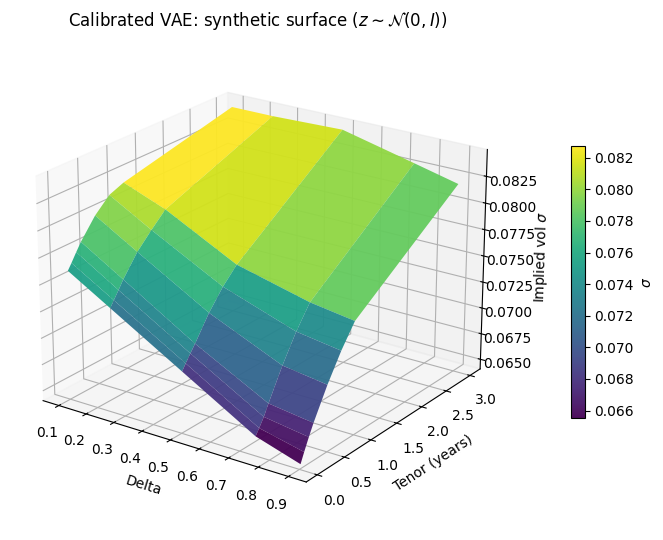

In [46]:
device = next(model.parameters()).device
model.eval()
with torch.no_grad():
    z_samp = torch.randn(1, cfg.latent_dim, device=device)
    gen_surface = model.decode(z_samp).cpu().numpy().squeeze(0)

n_t, n_d = len(TENORS_YEARS), len(DELTAS)
mat_gen = gen_surface.reshape(n_t, n_d)

# Mesh: tenor x delta (rows x cols) matches mat_gen[i, j]
T_grid, D_grid = np.meshgrid(TENORS_YEARS, DELTAS, indexing="ij")

fig = plt.figure(figsize=(8.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    D_grid,
    T_grid,
    mat_gen,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)
ax.set_xlabel("Delta")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel(r"Implied vol $\sigma$")
ax.set_title(r"Calibrated VAE: synthetic surface ($z \sim \mathcal{N}(0,I)$)")
ax.view_init(elev=22, azim=-55)
fig.colorbar(surf, ax=ax, shrink=0.55, label=r"$\sigma$", pad=0.08)
plt.tight_layout()
plt.show()

### Discrete no-arbitrage check (Black–76)

The decoder outputs vols on a fixed \((T,\delta)\) grid. Strikes **depend on tenor** (same mapping as `make_synthetic_sabr_surfaces`), so this is **not** a full rectangular strike×expiry matrix — we use `validate_vol_surface_per_expiry_black76`: on **each expiry**, Black–76 call prices from \(\sigma(K,T)\) must be monotone and discretely convex in \(K\); plus a **sticky-delta** sanity check that \(w=\sigma^2 T\) does not **decrease** along tenor within each \(\delta\) column (heuristic; not the same as fixed-\(K\) total variance). Grid-only diagnostics; interpolation between nodes is not covered.

In [15]:
importlib.reload(rates_models.arbitrage)
importlib.reload(rates_models.vae_surface)

forward = 0.03  # default in make_synthetic_sabr_surfaces (must match strike mapping)
K_grid = strikes_for_surface_grid(forward)

rep = validate_vol_surface_per_expiry_black76(
    K_grid,
    TENORS_YEARS,
    mat_gen,
    forward=forward,
)
print(f"Discrete Black-76 diagnostics pass (no violations): {rep.ok}")
print(f"Violation count: {len(rep.violations)}")
if rep.violations:
    print("\nMessages (up to 30):")
    for msg in rep.violations[:30]:
        print(" ", msg)

Discrete Black-76 diagnostics pass (no violations): True
Violation count: 0


## 2. Impute missing quotes (optimize latent $z$)

Fix the trained decoder and minimize MSE on **observed** grid points over $z$, as in the paper’s second step.

RMSE on hidden cells: 0.0018053423390656427


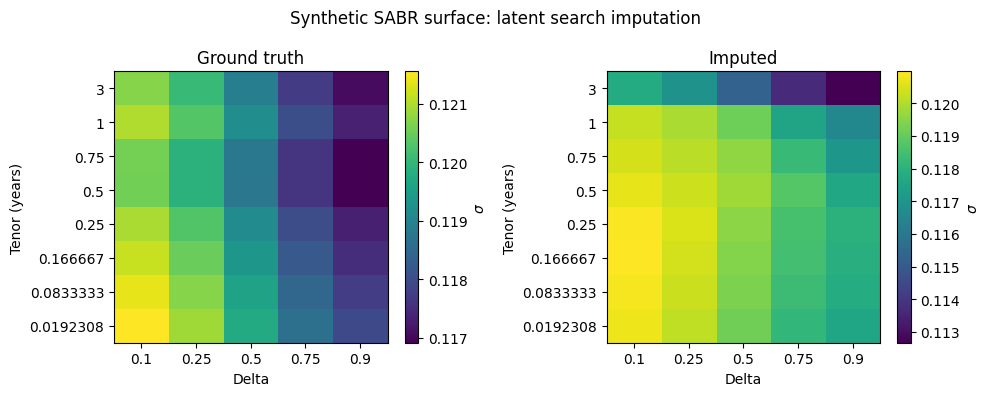

In [16]:
truth = surfaces[0]
mask = rng.random(truth.shape) > 0.45
z_hat, filled = impute_surface_latent_search(
    model, mask, truth, config=cfg, steps=500, lr=0.08
)

rmse = float(np.sqrt(np.mean((filled[~mask] - truth[~mask]) ** 2)))
print("RMSE on hidden cells:", rmse)

n_t, n_d = len(TENORS_YEARS), len(DELTAS)
mat_true = truth.reshape(n_t, n_d)
mat_fill = filled.reshape(n_t, n_d)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [mat_true, mat_fill], ["Ground truth", "Imputed"]):
    im = ax.imshow(mat, aspect="auto", origin="lower")
    ax.set_xticks(range(n_d))
    ax.set_xticklabels([f"{d:g}" for d in DELTAS])
    ax.set_yticks(range(n_t))
    ax.set_yticklabels([f"{t:g}" for t in TENORS_YEARS])
    ax.set_xlabel("Delta")
    ax.set_ylabel("Tenor (years)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=r"$\sigma$")
plt.suptitle("Synthetic SABR surface: latent search imputation")
plt.tight_layout()
plt.show()

## 4. Arbitrage-aware VAE (structural strike no-arb + calendar training)

**Option A — `constrained_strike_decoder=True` (recommended):** The decoder does **not** output σ freely. For each expiry it outputs five logits that are mapped to **Black–76 call prices** that are **strictly decreasing and discretely convex** in strike (no butterfly / strike monotonicity violations on that slice). Prices are capped to stay in the no-arbitrage interval, then σ is recovered with **bisection** in PyTorch (differentiable).

Additionally, set `enforce_full_noarb_layer=True` to activate a **built-in no-arbitrage projection layer inside decoder forward pass** (straight-through gradients). To keep training tractable, this layer is applied when decoding in eval/sampling mode; it makes `model.decode(...)` return surfaces that satisfy the current discrete checker directly (strike + sticky-delta), without a separate notebook repair step.

**Option B — unconstrained decoder:** Soft **squared** penalties + prior on `decode(z)` for `z \sim \mathcal{N}(0,I)`; does not guarantee the checker. You can also add a smoothness penalty (squared second differences across tenor/delta) to suppress kinks and high-frequency oscillations.

**Encoder (optional):** `repair_targets=True` fits ELBO on repaired synthetic surfaces (slow).

The next cells train **Option A** by default and validate the decoded sample.

In [39]:
importlib.reload(rates_models.arbitrage_repair)
importlib.reload(rates_models.vae_surface)

# Set True to train on repaired surfaces (slow preprocessing). False = decoder penalty only (faster).
USE_REPAIRED_TARGETS = False

n_train_af = 1000
surfaces_af = make_synthetic_sabr_surfaces(n_train_af, rng=rng)
cfg_af = TrainConfig(epochs=35, batch_size=64, latent_dim=16, lr=8e-4, kl_weight=0.4)
arb_cfg = ArbitrageAwareConfig(
    forward=0.03,
    constrained_strike_decoder=True,
    enforce_full_noarb_layer=True,
    full_noarb_max_iter=20,
    lambda_arb=1.0,
    butterfly_weight=4.0,
    sticky_weight=0.5,
    prior_arb_weight=0.2,
    smoothness_weight=0.02,
    smoothness_tenor_weight=1.0,
    smoothness_delta_weight=0.25,
    repair_targets=USE_REPAIRED_TARGETS,
    repair_max_iter=10,
)

if USE_REPAIRED_TARGETS:
    print("Repairing training surfaces (this can take several minutes)...")
model_af, losses_af, comps_af = train_vae_arbitrage_aware(
    surfaces_af,
    cfg_af,
    arb_cfg,
    return_components=True,
)


In [19]:
device_af = next(model_af.parameters()).device
model_af.eval()
with torch.no_grad():
    z_af = torch.randn(1, cfg_af.latent_dim, device=device_af)
    gen_af = model_af.decode(z_af).cpu().numpy().squeeze(0)

mat_af = gen_af.reshape(len(TENORS_YEARS), len(DELTAS))
K_grid_af = strikes_for_surface_grid(0.03)

importlib.reload(rates_models.arbitrage)
importlib.reload(rates_models.vae_surface)

rep_af = validate_vol_surface_per_expiry_black76(
    K_grid_af,
    TENORS_YEARS,
    mat_af,
    forward=0.03,
)
strike_msgs = [m for m in rep_af.violations if "Sticky-delta" not in m]
sticky_msgs = [m for m in rep_af.violations if "Sticky-delta" in m]
print("Decoder output — full pass:", rep_af.ok, "| total violations:", len(rep_af.violations))
print("  Strike-slice (mono/butterfly) messages:", len(strike_msgs), "| Sticky-delta messages:", len(sticky_msgs))
if rep_af.violations:
    for msg in rep_af.violations[:12]:
        print(" ", msg)

Decoder output — full pass: True | total violations: 0
  Strike-slice (mono/butterfly) messages: 0 | Sticky-delta messages: 0


## 5. Large-data calibration with constraints on both sides

This experiment uses **60,000** synthetic surfaces and applies constraints during **calibration** on:

1. **Encoder/data side:** `repair_targets=True` with **strict filtering** (only repaired targets that actually pass checker are kept; otherwise dropped/retried).
2. **Decoder side:** arbitrage penalties in the loss (`lambda_arb`, `prior_arb_weight`, etc.).

During **simulation/evaluation**, constraints are disabled in the sense that we sample and validate the **raw decoder output** directly (no repair / no projection at inference). This tests whether learned weights alone avoid arbitrage.

> Runtime note: this is very heavy, especially with target repair on 60k samples.

Large-data run config: ArbitrageAwareConfig(forward=0.03, lambda_arb=4.0, mono_weight=1.0, butterfly_weight=12.0, sticky_weight=1.0, prior_arb_weight=1.0, smoothness_weight=2.0, smoothness_tenor_weight=1.0, smoothness_delta_weight=1.0, repair_targets=True, repair_max_iter=10, repair_retry_scales=(1, 2, 4), strict_repair_targets=True, min_repaired_fraction=0.9, constrained_strike_decoder=False, enforce_full_noarb_layer=False, full_noarb_max_iter=20)
Repairing training targets strictly + decoder loss constraints during calibration...
repair_targets summary: kept 6000/6000 (100.0%), dropped 0 (strict=True)


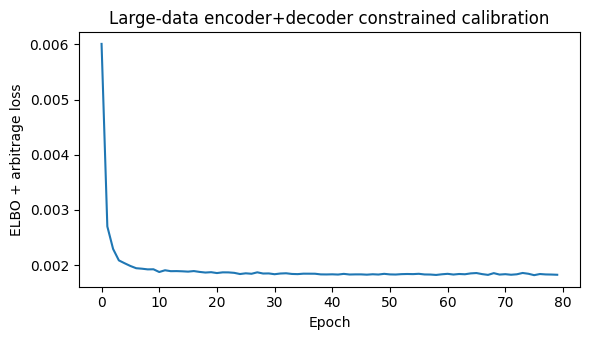

In [25]:
importlib.reload(rates_models.vae_surface)
from rates_models.vae_surface import (
    ArbitrageAwareConfig,
    TrainConfig,
    make_synthetic_sabr_surfaces,
    train_vae_arbitrage_aware,
)

n_train_big = 6000
epochs_big = 100

surfaces_big = make_synthetic_sabr_surfaces(n_train_big, rng=rng)
cfg_big = TrainConfig(
    epochs=epochs_big,
    batch_size=256,
    latent_dim=16,
    lr=8e-4,
    kl_weight=0.35,
)

# Rebalanced regularization to avoid over-smoothing / mode collapse.
# Keep constraints, but make them gentle enough to preserve smile curvature.
arb_big = ArbitrageAwareConfig(
    forward=0.03,
    constrained_strike_decoder=False,
    enforce_full_noarb_layer=False,
    lambda_arb=0.7,
    butterfly_weight=4.0,
    sticky_weight=0.6,
    prior_arb_weight=0.2,
    smoothness_weight=0.05,
    smoothness_tenor_weight=1.0,
    smoothness_delta_weight=0.25,
    repair_targets=True,
    repair_max_iter=10,
    repair_retry_scales=(1, 2, 4),
    strict_repair_targets=True,
    min_repaired_fraction=0.9,
)

print("Large-data run config:", arb_big)
print("Repairing training targets strictly + decoder loss constraints during calibration...")
model_big, losses_big = train_vae_arbitrage_aware(surfaces_big, cfg_big, arb_big)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(losses_big)
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO + arbitrage loss")
ax.set_title("Large-data encoder+decoder constrained calibration")
plt.tight_layout()
plt.show()

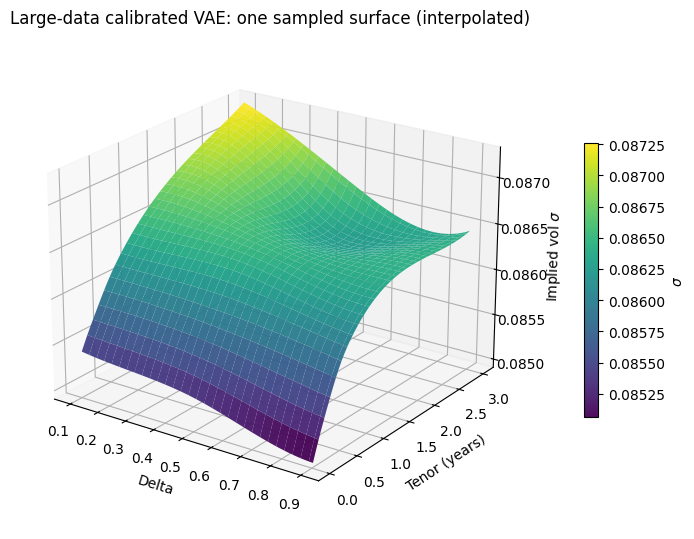

In [45]:
# One sampled surface from the calibrated large-data VAE
from scipy.interpolate import RectBivariateSpline

model_big.eval()
device_big = next(model_big.parameters()).device
with torch.no_grad():
    z_plot = torch.randn(1, cfg_big.latent_dim, device=device_big)
    gen_plot = model_big.decode(z_plot).cpu().numpy().squeeze(0)

mat_plot = gen_plot.reshape(len(TENORS_YEARS), len(DELTAS))

# Interpolate to a denser plotting grid for smoother rendering.
n_t_fine = 60
n_d_fine = 60
tenors_fine = np.linspace(float(TENORS_YEARS.min()), float(TENORS_YEARS.max()), n_t_fine)
deltas_fine = np.linspace(float(DELTAS.min()), float(DELTAS.max()), n_d_fine)
spline = RectBivariateSpline(TENORS_YEARS, DELTAS, mat_plot, kx=3, ky=3)
mat_plot_fine = spline(tenors_fine, deltas_fine)
T_grid_plot, D_grid_plot = np.meshgrid(tenors_fine, deltas_fine, indexing="ij")

fig = plt.figure(figsize=(8.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    D_grid_plot,
    T_grid_plot,
    mat_plot_fine,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)
ax.set_xlabel("Delta")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel(r"Implied vol $\sigma$")
ax.set_title("Large-data calibrated VAE: one sampled surface (interpolated)")
ax.view_init(elev=22, azim=-55)
fig.colorbar(surf, ax=ax, shrink=0.55, label=r"$\sigma$", pad=0.08)
plt.tight_layout()
plt.show()

In [23]:
importlib.reload(rates_models.arbitrage)
importlib.reload(rates_models.vae_surface)
from rates_models.vae_surface import surface_smoothness_penalty_torch

# Evaluate sampled decoder outputs under the same discrete checker.
K_big = strikes_for_surface_grid(0.03)
model_big.eval()
n_eval = 5000
passes = 0
viol_counts = []

n_any_arb = 0
n_strike_arb = 0
n_sticky_arb = 0
n_both_arb = 0

smooth_vals = []

with torch.no_grad():
    z_big = torch.randn(n_eval, cfg_big.latent_dim, device=next(model_big.parameters()).device)
    dec_big = model_big.decode(z_big)
    gen_big = dec_big.cpu().numpy()

    # Batch smoothness diagnostic on generated surfaces.
    smooth_all = surface_smoothness_penalty_torch(
        dec_big,
        tenor_weight=arb_big.smoothness_tenor_weight,
        delta_weight=arb_big.smoothness_delta_weight,
    )

# Vectorized per-sample smoothness for distribution stats.
if len(TENORS_YEARS) >= 3:
    d2_t = gen_big[:, 2:, :] - 2.0 * gen_big[:, 1:-1, :] + gen_big[:, :-2, :]
    smooth_t = np.mean(d2_t**2, axis=(1, 2))
else:
    smooth_t = np.zeros(gen_big.shape[0])
if len(DELTAS) >= 3:
    d2_d = gen_big[:, :, 2:] - 2.0 * gen_big[:, :, 1:-1] + gen_big[:, :, :-2]
    smooth_d = np.mean(d2_d**2, axis=(1, 2))
else:
    smooth_d = np.zeros(gen_big.shape[0])
smooth_vals = (
    arb_big.smoothness_tenor_weight * smooth_t
    + arb_big.smoothness_delta_weight * smooth_d
)

for i in range(n_eval):
    mat_i = gen_big[i].reshape(len(TENORS_YEARS), len(DELTAS))
    rep_i = validate_vol_surface_per_expiry_black76(K_big, TENORS_YEARS, mat_i, forward=0.03)

    passes += int(rep_i.ok)
    viol_counts.append(len(rep_i.violations))

    has_strike = any("Sticky-delta" not in msg for msg in rep_i.violations)
    has_sticky = any("Sticky-delta" in msg for msg in rep_i.violations)

    if has_strike or has_sticky:
        n_any_arb += 1
    if has_strike:
        n_strike_arb += 1
    if has_sticky:
        n_sticky_arb += 1
    if has_strike and has_sticky:
        n_both_arb += 1


print(f"Raw decoder after encoder+decoder constrained calibration — arbitrage-free samples: {passes}/{n_eval} = {passes/n_eval:.1%}")
print(f"Samples with any arbitrage: {n_any_arb}/{n_eval} = {n_any_arb/n_eval:.1%}")
print(f"Samples with strike arbitrage: {n_strike_arb}/{n_eval} = {n_strike_arb/n_eval:.1%}")
print(f"Samples with sticky-delta arbitrage: {n_sticky_arb}/{n_eval} = {n_sticky_arb/n_eval:.1%}")
print(f"Samples with both strike + sticky: {n_both_arb}/{n_eval} = {n_both_arb/n_eval:.1%}")
print(f"Mean violations per sample: {np.mean(viol_counts):.2f}")
print(f"Median violations per sample: {np.median(viol_counts):.2f}")
print(f"Min/Max violations: {np.min(viol_counts)} / {np.max(viol_counts)}")
print(f"Smoothness penalty (batch): {float(smooth_all.item()):.6g}")
print(f"Smoothness per sample mean/median/min/max: {np.mean(smooth_vals):.6g} / {np.median(smooth_vals):.6g} / {np.min(smooth_vals):.6g} / {np.max(smooth_vals):.6g}")

Raw decoder after encoder+decoder constrained calibration — arbitrage-free samples: 4997/5000 = 99.9%
Samples with any arbitrage: 3/5000 = 0.1%
Samples with strike arbitrage: 3/5000 = 0.1%
Samples with sticky-delta arbitrage: 0/5000 = 0.0%
Samples with both strike + sticky: 0/5000 = 0.0%
Mean violations per sample: 0.00
Median violations per sample: 0.00
Min/Max violations: 0 / 1


## 6. Notes

- **Arbitrage:** Discrete checks are in `rates_models.arbitrage`. **Section 4** uses `train_vae_arbitrage_aware` with **`constrained_strike_decoder=True`** so each expiry slice has **no strike butterfly / monotonicity violations** by construction; **calendar** (sticky total variance) is still trained, not hard-coded.
- **Data:** Replace `make_synthetic_sabr_surfaces` with your historical surface vectors aligned to the same **40** `(tenor, delta)` layout.
- **Hyperparameters:** Learning rate, batch size, and latent dimension were tuned in the paper via validation on held-out time periods.